# Temas Tratados en el Trabajo Práctico 4

* Representación del Conocimiento y Razonamiento Lógico.

* Estrategias de resolución de hipótesis: Encadenamiento hacia Adelante, Encadenamiento hacia Atrás y Resolución por Contradicción.

* Representación basada en circuitos.

## Ejercicios Teóricos

1. ¿Qué es una inferencia?

### Resolución

Una **inferencia** es el proceso mediante el cual se obtiene una nueva conclusión a partir de información que ya se conoce. En lógica, la información inicial se almacena en una **base de conocimiento** y las conclusiones se obtienen aplicando reglas de inferencia válidas.

Si la base de conocimiento contiene:

$$
p \rightarrow q
$$

$$
p
$$

se puede aplicar **Modus Ponens** e inferir:

$$
q
$$

La relación entre la base de conocimiento $BC$ y una conclusión $\alpha$ puede expresarse de dos maneras:

- $BC \models \alpha$: $\alpha$ es una **consecuencia lógica** de la base de conocimiento.
- $BC \vdash \alpha$: $\alpha$ puede obtenerse mediante una secuencia de reglas de inferencia.

Por lo tanto, inferir no consiste en adivinar una conclusión, sino en derivarla de manera justificada a partir del conocimiento disponible.

2. ¿Cómo se verifica que un modelo se infiere de la base de conocimientos?

### Resolución

Un **modelo** es una asignación de valores de verdad a las proposiciones. Un modelo satisface una sentencia cuando dicha sentencia resulta verdadera bajo esa asignación.

Formalmente, para verificar que una hipótesis $\alpha$ se infiere de una base de conocimiento $BC$, se debe comprobar que $\alpha$ sea verdadera en **todos los modelos en los que la base de conocimiento es verdadera**:

$$
BC \models \alpha
$$

De manera equivalente, el conjunto de modelos de la base debe estar incluido en el conjunto de modelos de la hipótesis:

$$
M(BC) \subseteq M(\alpha)
$$

Esto puede verificarse mediante **comprobación de modelos**:

1. Se generan las posibles asignaciones de verdad de las proposiciones.
2. Se seleccionan aquellas que hacen verdadera la base de conocimiento.
3. Se comprueba si la hipótesis también es verdadera en todas ellas.

Si existe al menos un modelo donde $BC$ sea verdadera y $\alpha$ sea falsa, ese modelo es un **contraejemplo** y la inferencia no es válida.

> En sentido estricto, no se dice que un modelo se infiere de la base, sino que una sentencia o hipótesis se infiere de ella al ser verdadera en todos sus modelos.

3. Observe la siguiente base de conocimiento:

$R1: b ∧ c → a$

$R2: d ∧ e → b$

$R3: g ∧ e → b$

$R4: e → c$

$R5: d$

$R6: e$

$R7: a ∧ g → f$

        3.1 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia adelante? Este método solamente usa reglas ya incorporadas a la base de conocimiento para inferir la hipótesis, ¿qué propiedad debe tener el algoritmo para asegurar que esta inferencia sea posible?

        3.2 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia atrás? Este método asigna un valor de verdad a la hipótesis y deriva las sentencias de la base de conocimiento, ¿qué propiedad debe tener el algoritmo para asegurar que esta derivación sea posible?

        3.3 Exprese la base de conocimiento en su Forma Normal Conjuntiva. A continuación, demuestre por contradicción que $a = True$.

### Resolución

Las reglas $R_1$, $R_2$, $R_3$, $R_4$ y $R_7$ son implicaciones, mientras que $R_5$ y $R_6$ son los hechos iniciales:

$$
d, \qquad e
$$

#### 3.1 Encadenamiento hacia adelante

El encadenamiento hacia adelante está **dirigido por los datos**: comienza con los hechos conocidos y aplica las reglas cuyas premisas ya se cumplen.

**Hechos iniciales:**

$$
H_0=\{d,e\}
$$

1. Como $d$ y $e$ son verdaderos, se activa $R_2$:

$$
d \land e \rightarrow b
$$

Por lo tanto, se infiere $b$.

2. Como $e$ es verdadero, también se activa $R_4$:

$$
e \rightarrow c
$$

Por lo tanto, se infiere $c$.

3. Ahora se conocen $b$ y $c$, por lo que se activa $R_1$:

$$
b \land c \rightarrow a
$$

En consecuencia:

$$
a=True
$$

La cadena de inferencias es:

$$
\{d,e\} \Rightarrow \{b,c\} \Rightarrow a
$$

El algoritmo debe ser **correcto o sólido**, para no derivar conclusiones que no estén implicadas por la base, y **completo**, para encontrar la hipótesis siempre que esta sea consecuencia de la base. La propiedad solicitada para asegurar que el procedimiento pueda encontrar $a$ es principalmente la **completitud**. El encadenamiento hacia adelante es correcto y completo para bases formadas por cláusulas de Horn.

#### 3.2 Encadenamiento hacia atrás

El encadenamiento hacia atrás está **dirigido por el objetivo**. Se comienza con la hipótesis $a$ y se buscan reglas capaces de concluirla. No se supone arbitrariamente que $a$ es verdadera: se intenta justificarla reduciéndola a hechos conocidos.

1. **Objetivo inicial:** demostrar $a$. La regla que concluye $a$ es $R_1$:

$$
b \land c \rightarrow a
$$

Por lo tanto, aparecen los subobjetivos $b$ y $c$.

2. Para demostrar $b$ se puede utilizar $R_2$:

$$
d \land e \rightarrow b
$$

Sus premisas $d$ y $e$ están presentes como hechos en $R_5$ y $R_6$. Entonces, $b$ queda demostrado. La regla $R_3$ ofrece otro camino para $b$, pero requeriría demostrar $g$, que no aparece como hecho ni como conclusión de otra regla.

3. Para demostrar $c$ se utiliza $R_4$:

$$
e \rightarrow c
$$

Como $e$ es un hecho, $c$ queda demostrado.

4. Al haberse demostrado $b$ y $c$, se satisface el cuerpo de $R_1$ y se concluye:

$$
a=True
$$

La reducción de objetivos puede resumirse así:

$$
a \Leftarrow (b \land c) \Leftarrow [(d \land e) \land e]
$$

El algoritmo también debe ser **correcto** y **completo**. La completitud asegura que, si existe una demostración de la consulta utilizando las cláusulas de Horn de la base, una búsqueda sistemática podrá encontrarla.

#### 3.3 Forma Normal Conjuntiva y demostración por contradicción

Para convertir cada implicación a Forma Normal Conjuntiva se utiliza:

$$
p \rightarrow q \equiv \neg p \lor q
$$

Cuando la premisa es una conjunción:

$$
p \land q \rightarrow r
\equiv
\neg p \lor \neg q \lor r
$$

La base de conocimiento en FNC queda formada por las siguientes cláusulas:

$$
C_1: \neg b \lor \neg c \lor a
$$

$$
C_2: \neg d \lor \neg e \lor b
$$

$$
C_3: \neg g \lor \neg e \lor b
$$

$$
C_4: \neg e \lor c
$$

$$
C_5: d
$$

$$
C_6: e
$$

$$
C_7: \neg a \lor \neg g \lor f
$$

Por lo tanto:

$$
BC=C_1 \land C_2 \land C_3 \land C_4 \land C_5 \land C_6 \land C_7
$$

Para demostrar $a$ por contradicción se agrega la negación de la consulta:

$$
C_8: \neg a
$$

Luego se aplica resolución:

1. Resolviendo $C_2$ con $C_5=d$:

$$
C_9: \neg e \lor b
$$

2. Resolviendo $C_9$ con $C_6=e$:

$$
C_{10}: b
$$

3. Resolviendo $C_4$ con $C_6=e$:

$$
C_{11}: c
$$

4. Resolviendo $C_1$ con $C_8=\neg a$:

$$
C_{12}: \neg b \lor \neg c
$$

5. Resolviendo $C_{12}$ con $C_{10}=b$:

$$
C_{13}: \neg c
$$

6. Finalmente, al resolver $C_{13}=\neg c$ con $C_{11}=c$, se obtiene la cláusula vacía:

$$
\square
$$

La cláusula vacía representa una contradicción. Por lo tanto, $BC \land \neg a$ es insatisfacible y queda demostrado que:

$$
\boxed{BC \models a}
$$

Las cláusulas provenientes de $R_3$ y $R_7$ forman parte de la base, pero no fue necesario utilizarlas para esta demostración.

4. Diseñe con lógica proposicional basada en circuitos las proposiciones *OrientadoDerecha* y *Agente ubicado en la casilla [1,2]* para el mundo de wumpus de 4x4. Dibuje el circuito correspondiente.


5. El nonograma es un juego en el cual se posee un tablero en blanco y cada fila y columna presenta información sobre la longitud de un bloque en dicha fila/columna. Además, la leyenda puede indicar más de un número, indicando esto que existen varios bloques de las longitudes mostradas por la leyenda y en el mismo orden, separados por al menos un espacio vacío.

Resuelva el nonograma de la imagen de abajo escribiendo en primer lugar cada regla que puede incorporarse a la base de conocimientos inicial e incorporando cada inferencia que realice.

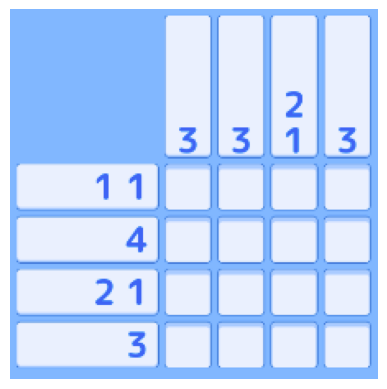

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1SKiXvrI_TX-U4sbw60TYSRmaNYyFixmI"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Implementar un motor de inferencia con encadenamiento hacia adelante. Pruébelo con las proposiciones del ejercicio 3.

### 6. Motor de inferencia con encadenamiento hacia adelante

#### Fundamento del método

El encadenamiento hacia adelante es un método de inferencia **dirigido por los datos**. Comienza con los hechos conocidos y aplica sucesivamente las reglas cuyas premisas son verdaderas, incorporando cada conclusión obtenida como un nuevo hecho. El procedimiento termina cuando alcanza el objetivo o cuando ninguna regla puede generar información nueva.

La base del ejercicio 3 está formada por **cláusulas de Horn definidas**, porque cada regla tiene una conjunción de premisas y una única conclusión positiva:

$$
p_1 \land p_2 \land \cdots \land p_n \rightarrow q
$$

Este tipo de base permite utilizar un encadenamiento hacia adelante correcto y completo.

#### Descomposición y normalización de las reglas

Para aplicar el algoritmo, cada implicación se separa en dos componentes:

- un conjunto de **premisas**, que deben cumplirse simultáneamente;
- una única **conclusión**, que se agrega cuando se cumplen todas las premisas.

Por ejemplo, la regla $R_1$ puede transformarse algebraicamente de la siguiente manera:

$$
b \land c \rightarrow a
\equiv
\neg(b \land c) \lor a
\equiv
\neg b \lor \neg c \lor a
$$

La última expresión es su cláusula de Horn en FNC. Para el encadenamiento hacia adelante se utiliza la forma equivalente de regla de producción:

$$
\{b,c\} \rightarrow a
$$

No debe descomponerse incorrectamente en $b\rightarrow a$ y $c\rightarrow a$, porque $R_1$ exige que **ambas premisas** sean verdaderas. En el programa, el método `issubset` realiza precisamente esta comprobación.

La base se carga así:

| Sentencia | Tipo | Premisas | Conclusión |
|---|---|---|---|
| $R_1:b\land c\rightarrow a$ | Regla | $\{b,c\}$ | $a$ |
| $R_2:d\land e\rightarrow b$ | Regla | $\{d,e\}$ | $b$ |
| $R_3:g\land e\rightarrow b$ | Regla | $\{g,e\}$ | $b$ |
| $R_4:e\rightarrow c$ | Regla | $\{e\}$ | $c$ |
| $R_5:d$ | Hecho | — | $d$ |
| $R_6:e$ | Hecho | — | $e$ |
| $R_7:a\land g\rightarrow f$ | Regla | $\{a,g\}$ | $f$ |

Por lo tanto, el conjunto inicial de hechos es:

$$
H_0=\{d,e\}
$$

#### Regla de inferencia utilizada

El motor aplica **Modus Ponens generalizado**:

$$
\frac{p_1 \land \cdots \land p_n \rightarrow q,\quad p_1,\ldots,p_n}{q}
$$

Es decir, una regla solamente puede activarse cuando todas sus premisas pertenecen al conjunto de hechos conocidos.

#### Funcionamiento del algoritmo

En cada iteración, el motor:

1. busca las reglas cuyas premisas estén contenidas en los hechos conocidos;
2. descarta las que producirían una conclusión ya conocida;
3. selecciona una regla aplicable;
4. incorpora su conclusión como un nuevo hecho;
5. registra la regla utilizada para poder explicar la demostración.

Si no queda ninguna regla que produzca información nueva, se alcanza un **punto fijo**. En ese momento, si el objetivo no está entre los hechos, no puede demostrarse mediante esta base.

#### Heurística de selección

El encadenamiento hacia adelante no necesita una heurística para ser correcto: podría aplicar todas las reglas habilitadas hasta alcanzar el cierre de la base. Sin embargo, cuando varias reglas pueden activarse al mismo tiempo, hace falta un criterio sencillo para decidir cuál aplicar primero.

Se utiliza la **heurística de especificidad**: se prioriza la regla aplicable que tenga la mayor cantidad de premisas. Una regla con más condiciones representa una situación más específica y, normalmente, aprovecha una mayor cantidad de la información disponible. En caso de empate se mantiene el orden de carga de la base, lo que hace que la ejecución sea determinista.

Además, se aplica el criterio de **novedad**: no se ejecuta una regla si su conclusión ya es conocida, porque repetirla no modifica la base.

La heurística solamente modifica el orden de activación. No afecta la corrección ni la completitud, porque:

- únicamente se eligen reglas cuyas premisas ya son verdaderas;
- las reglas no elegidas permanecen disponibles para iteraciones posteriores;
- el procedimiento continúa hasta demostrar el objetivo o alcanzar el punto fijo.

Para este ejercicio, la secuencia esperada es:

$$
\{d,e\}
\xRightarrow{R_2}
\{d,e,b\}
\xRightarrow{R_4}
\{d,e,b,c\}
\xRightarrow{R_1}
\{d,e,b,c,a\}
$$

Así, el motor debe concluir que $a=True$.

In [ ]:
from dataclasses import dataclass  #permite crear clases destinadas principalmente a almacenar datos sin escribir manualmente un constructor

#cada objeto de la clase REGLA es una expresion b∧c→a
@dataclass(frozen=True)
class Regla:
    """Representa una regla de Horn: premisa_1 ∧ ... ∧ premisa_n → conclusión."""

    nombre: str
    premisas: frozenset[str]  #las premisas deben ser un conjunto inmutable de cadenas, solo set seria modificable
    conclusion: str

#recibe lo que se sabe al iniciar (hechos y reglas) (base de conocimiento), y el objetivo que es lo que queremos comprobar
def encadenamiento_hacia_adelante(hechos_iniciales, reglas, objetivo):
    """
    Intenta demostrar un objetivo mediante encadenamiento hacia adelante.

    Retorna:
        demostrado: indica si el objetivo pudo inferirse.
        hechos: conjunto final de hechos conocidos.
        traza: reglas utilizadas, en el orden en que se aplicaron.
    """

    # Se crea una copia de lo recibido para no modificar el conjunto original.
    hechos = set(hechos_iniciales) #asi podemos agregar nuevas conclusiones sin modificar lo que esta
    reglas_pendientes = list(reglas)
    traza = []  #lista inicialmente vacia en la que vamos a guardar las reglas utilizadas

#realizamos el bucle hasta que el objetivo sea un hecho
    while objetivo not in hechos:
        # Una regla es aplicable cuando todas sus premisas son hechos
        # conocidos y su conclusión todavía aporta información nueva.
        reglas_aplicables = []

        reglas_aplicables = [
            regla
            for regla in reglas_pendientes 
            if regla.premisas.issubset(hechos)  #comprueba si las premisas de la regla se encuentran entre los hechos.
            and regla.conclusion not in hechos  #esta condicion impide agregar reglas que no produzcan info nueva

            #por ejemplo para R2 regla.premisas = {"d", "e"} y hechos = {"d", "e"}
            #entonces issubset produce → TRUE
            #y eso nos permite aplicar d∧e→b

            #en cmbio para R3 {"g", "e"}.issubset({"d", "e"}) produce FALSE, porque g no es un hecho conocido
        ]
        

        # Si ninguna regla puede producir un hecho nuevo, se alcanzó
        # un punto fijo y el objetivo no puede demostrarse.
        if not reglas_aplicables:
            break

        # Heurística de especificidad: se prioriza la regla aplicable
        # con mayor cantidad de premisas. En caso de empate se conserva
        # el orden en el que las reglas fueron cargadas.
        regla_elegida = max(
            reglas_aplicables,
            key=lambda regla: len(regla.premisas),  #la funcion lambda recibe una regla y devuelve la cantidad de premisas
            #por lo tanto se elige la que tiene mas premisas
        )

        # Aplicación de Modus Ponens: si las premisas son verdaderas,
        # se incorpora la conclusión como un nuevo hecho.
        hechos.add(regla_elegida.conclusion)
        traza.append(regla_elegida)
        reglas_pendientes.remove(regla_elegida)

    return objetivo in hechos, hechos, traza  #la funcion devuelve si el objetivo fue verificado, hechos finales, reglas utilizadas


# Las implicaciones del ejercicio 3 se cargan como reglas de Horn. Son la base de conocimiento
reglas_ejercicio_3 = [
    Regla("R1", frozenset({"b", "c"}), "a"),
    Regla("R2", frozenset({"d", "e"}), "b"),
    Regla("R3", frozenset({"g", "e"}), "b"),
    Regla("R4", frozenset({"e"}), "c"),
    Regla("R7", frozenset({"a", "g"}), "f"),
]

# R5: d y R6: e no son implicaciones, sino hechos iniciales.
hechos_iniciales = {"d", "e"}
objetivo = "a"

demostrado, hechos_finales, traza = encadenamiento_hacia_adelante(
    hechos_iniciales,
    reglas_ejercicio_3,
    objetivo,
)

print("Hechos iniciales:", sorted(hechos_iniciales))
print("\nReglas aplicadas:")

for numero, regla in enumerate(traza, start=1):
    premisas = " ∧ ".join(sorted(regla.premisas))
    print(f"{numero}. {regla.nombre}: {premisas} → {regla.conclusion}")

print("\nHechos finales:", sorted(hechos_finales))
print(f"¿Se demostró que {objetivo} = True?: {demostrado}")

Hechos iniciales: ['d', 'e']

Reglas aplicadas:
1. R2: d ∧ e → b
2. R4: e → c
3. R1: b ∧ c → a

Hechos finales: ['a', 'b', 'c', 'd', 'e']
¿Se demostró que a = True?: True


## 3. Traza de Ejecución Paso a Paso

* **Objetivo a demostrar:** `$a$`
* **Base de Hechos Inicial ($BH_0$):** `{"d", "e"}`

---

### Estado Inicial y Resolución de Conflicto
Con los hechos iniciales disponibles, dos reglas cumplen simultáneamente con la condición de activación ($Premisas \subseteq BH$):
* $R_2: d \land e \to b$ (2 premisas)
* $R_4: e \to c$ (1 premisa)

> **Criterio de especificidad:** Se selecciona $R_2$ por tener mayor cardinalidad de premisas ($\vert{}Premisas\vert{} = 2 > 1$).

---

### Iteración 1
* **Regla disparada:** $R_2: d \land e \to b$
* **Nuevo hecho inferido:** `"b"`
* **Estado del conjunto de hechos:**

  hechos = {"d", "e", "b"}

---

### Iteración 2

* **Reglas activables:** Únicamente $R_4: e \to c$ aporta información no contenida aún en la base de hechos.
* **Regla disparada:** $R_4: e \to c$
* **Nuevo hecho inferido:** `"c"`
* **Estado del conjunto de hechos:**


hechos = {"d", "e", "b", "c"}

---

### Iteración 3

* **Regla activable:** Al estar presentes tanto `b` como `c`, se satisfacen las premisas de $R_1$.
* **Regla disparada:** $R_1: b \land c \to a$
* **Nuevo hecho inferido:** `"a"`
* **Estado del conjunto de hechos:**

hechos = {"d", "e", "b", "c", "a"}

### Criterio de Parada

El objetivo `"a"` pasa a pertenecer al conjunto de hechos conocidos ($a \in BH$). La condición del bucle:


while objetivo not in hechos:
se evalúa como `False`. El algoritmo concluye con éxito demostrando que **$a$ es verdadero**.


### Prompt
Actúa como un docente y programador senior especializado en Inteligencia Artificial. Resuelve el Ejercicio 6 diseñando un cuaderno interactivo (formato script con celdas de Markdown explicativas) que implemente y valide un motor de inferencia basado en encadenamiento hacia adelante (forward chaining).  
Requerimientos técnicos:Modelado y base de conocimiento:Modela las implicaciones lógicas del Ejercicio 3 como reglas de Horn ($P_1 \land \dots \land P_n \to C$) utilizando estructuras inmutables (dataclass(frozen=True)).  
Separa formalmente los hechos atómicos iniciales ($d, e$) de las reglas condicionales ($R_1, R_2, R_3, R_4, R_7$) para demostrar el objetivo ($a$).  
Algoritmo del motor:  
 * Aplica sucesivamente Modus Ponens agregando conclusiones a la base de hechos hasta alcanzar el objetivo o un punto fijo (quiescence).
 * Retorna una traza clara de ejecución que registre las reglas disparadas en orden.  

Criterio de resolución de conflictos (Heurística):
* Implementa la heurística de especificidad (priorizar la regla aplicable con mayor número de premisas satisfechas) y preservación de orden de inserción en caso de empate.  

Explicación teórica (Celda Markdown):Redacta una celda conceptual en Markdown que preceda o acompañe al código justificando la elección de la heurística de especificidad, explicando la correspondencia con las reglas algebraicas/lógicas vistas en clase (Modus Ponens y forma clausal de Horn), y analizando el costo computacional/criterio de parada del algoritmo.

7. Implementar un motor de inferencia con encadenamiento hacia atrás. Pruébelo con las proposiciones del ejercicio 3.

### 7. Motor de inferencia con encadenamiento hacia atrás

#### Fundamento del método

El encadenamiento hacia atrás es un método de inferencia **dirigido por el objetivo**. En lugar de comenzar con los hechos y generar todas las conclusiones posibles, comienza con la hipótesis que se desea demostrar y busca reglas que puedan concluirla.

Es importante aclarar que el método no supone arbitrariamente que la hipótesis es verdadera. La toma como un **objetivo pendiente** e intenta justificarla hasta llegar a hechos conocidos.

Si se quiere demostrar:

$$
q
$$

y existe una regla:

$$
p_1\land p_2\land\cdots\land p_n\rightarrow q
$$

el objetivo se descompone en los subobjetivos:

$$
p_1,\ p_2,\ldots,\ p_n
$$

La demostración de $q$ tendrá éxito solamente si pueden demostrarse todas las premisas.

---

#### Relación con las reglas algebraicas

Una regla de Horn puede escribirse como implicación:

$$
p_1\land p_2\land\cdots\land p_n\rightarrow q
$$

o como una cláusula en Forma Normal Conjuntiva:

$$
\neg p_1\lor\neg p_2\lor\cdots\lor\neg p_n\lor q
$$

Ambas expresiones son equivalentes:

$$
p_1\land\cdots\land p_n\rightarrow q
\equiv
\neg(p_1\land\cdots\land p_n)\lor q
\equiv
\neg p_1\lor\cdots\lor\neg p_n\lor q
$$

Para el encadenamiento hacia atrás se utiliza la forma de implicación, ya que permite identificar directamente:

- la conclusión que puede satisfacer el objetivo;
- las premisas que deben convertirse en nuevos subobjetivos.

Por ejemplo:

$$
R_1:b\land c\rightarrow a
$$

permite descomponer el objetivo $a$ en:

$$
b\land c
$$

Esto no significa que se esté infiriendo $b$ y $c$ a partir de $a$. Simplemente se establece que ambos deben demostrarse para poder aplicar $R_1$ mediante Modus Ponens.

---

#### Aplicación a la base de conocimiento

El objetivo inicial es:

$$
a
$$

La única regla cuya conclusión es $a$ es:

$$
R_1:b\land c\rightarrow a
$$

Por lo tanto, aparecen los subobjetivos:

$$
b,\qquad c
$$

Para demostrar $b$ existen dos reglas posibles:

$$
R_2:d\land e\rightarrow b
$$

$$
R_3:g\land e\rightarrow b
$$

La regla $R_2$ puede satisfacerse directamente porque:

$$
R_5:d
$$

$$
R_6:e
$$

son hechos conocidos. Por lo tanto:

$$
d\land e\xRightarrow{R_2}b
$$

Para demostrar $c$ se utiliza:

$$
R_4:e\rightarrow c
$$

Como $e$ es un hecho:

$$
e\xRightarrow{R_4}c
$$

Finalmente, al haberse demostrado $b$ y $c$, puede aplicarse $R_1$:

$$
b\land c\xRightarrow{R_1}a
$$

La demostración completa es:

$$
a
\Leftarrow
(b\land c)
\Leftarrow
[(d\land e)\land e]
$$

---

#### Heurística seleccionada

Para un mismo objetivo pueden existir varias reglas candidatas. Por ejemplo, tanto $R_2$ como $R_3$ permiten concluir $b$.

Se utiliza la heurística de **menor cantidad de subobjetivos pendientes**. Se prioriza la regla que tenga la mayor cantidad de premisas presentes entre los hechos conocidos.

Para demostrar $b$:

- $R_2$ necesita $d$ y $e$, y ambos son hechos;
- $R_3$ necesita $g$ y $e$, pero $g$ no es un hecho conocido.

Por este motivo, se intenta primero $R_2$.

Esta heurística es adecuada porque reduce la cantidad de búsquedas innecesarias y favorece los caminos que están más próximos a los hechos disponibles. Sin embargo, solamente modifica el orden de búsqueda: si la primera regla falla, el algoritmo intenta las alternativas restantes mediante **backtracking**.

Por lo tanto, la heurística no afecta la completitud del método para esta base finita de cláusulas de Horn.

---

#### Controles implementados

El motor incorpora:

- comprobación directa de hechos;
- selección de reglas según su conclusión;
- descomposición de conjunciones en subobjetivos;
- backtracking cuando una regla no permite completar la demostración;
- detección de ciclos mediante el registro de objetivos actualmente visitados;
- una traza con las reglas que forman la demostración.

La detección de ciclos evita recursiones infinitas en bases que contengan reglas como:

$$
p\rightarrow q
\qquad
q\rightarrow p
$$

In [ ]:
def encadenamiento_hacia_atras(hechos_iniciales, reglas, objetivo):
    """
    Intenta demostrar un objetivo mediante encadenamiento hacia atrás.

    Retorna:
        demostrado: indica si el objetivo pudo demostrarse.
        traza: reglas utilizadas para construir la demostración.
    """

    # Se crea una copia para no modificar el conjunto recibido.
    hechos = set(hechos_iniciales)

#Su trabajo es intentar demostrar una proposición particular. Por ejemplo: demostrar("a", set())
    def demostrar(objetivo_actual, objetivos_en_camino): #funcion interna 'demostrar'
        """
        Demuestra recursivamente un objetivo.

        objetivos_en_camino contiene los objetivos que se están intentando
        demostrar en la rama actual y permite detectar ciclos.
        """

        # Caso base: el objetivo ya es un hecho conocido.
        if objetivo_actual in hechos:
            return True, []

        # Si el objetivo ya aparece en esta rama, existe un ciclo. Evita que entre en una recursión infinita
        if objetivo_actual in objetivos_en_camino:
            return False, []

        # Solo interesan las reglas que pueden concluir el objetivo actual.
        reglas_candidatas = [
            regla
            for regla in reglas
            if regla.conclusion == objetivo_actual  #buscamos las reglas con regla.conclusion == "a"
        ]

        # Heurística: probar primero la regla con menos premisas pendientes de demostración.
        reglas_candidatas.sort(
            key=lambda regla: (
                len(regla.premisas - hechos), #cantidad de premisas no conocidas. Es decir, esa expresion calcula que cantidad de premisas no son hechos aun
                len(regla.premisas),  # cantidad total de premisas
            )

            #por ejemplo para R2 {"d", "e"} - {"d", "e"} → el resultado es set();
            #no queda ninguna premisa pendiente

            #para R3: {"g", "e"} - {"d", "e"}, el resultado es {"g"}
            #Por eso se intenta primero \(R_2\).
        )

        # Se agrega el objetivo actual al camino de esta rama. Si objetivos_en_camino = {"a"} y objetivo_actual = "b" → nuevo_camino = {"a", "b"}
        nuevo_camino = objetivos_en_camino | {objetivo_actual}

        # Se prueban las reglas candidatas una por una.
        for regla in reglas_candidatas:
            traza_regla = []  #almacenará la demostración obtenida por esa regla.
            regla_demostrada = True

            # Una conjunción requiere demostrar todas sus premisas.
            for premisa in sorted(regla.premisas):
                demostrada, subtraza = demostrar(premisa, nuevo_camino,) #cada regla se convierte en un subobjetivo. LLAMADA RECURSIVA

                if not demostrada:  #si la conjuncion completa no puede demostrarse, entonces es FALSA
                    regla_demostrada = False
                    break

                traza_regla.extend(subtraza)  #extend agrega a una lista todos los elementos de otra lista.

            # Si todas las premisas fueron demostradas, puede aplicarse
            # Modus Ponens y concluir el objetivo actual.
            if regla_demostrada:
                traza_regla.append(regla)
                return True, traza_regla

            # Si la regla falla, el bucle continúa con otra alternativa.
            # Este comportamiento constituye el backtracking.

        # Ninguna regla permitió demostrar el objetivo.
        return False, []

    return demostrar(objetivo, set())


# R5: d y R6: e son los hechos iniciales.
hechos_iniciales = {"d", "e"}

# Hipótesis que se quiere demostrar.
objetivo = "a"

demostrado, traza = encadenamiento_hacia_atras(
    hechos_iniciales,
    reglas_ejercicio_3,
    objetivo,
)

print("Hechos conocidos:", sorted(hechos_iniciales))
print(f"Objetivo: {objetivo}")
print("\nReglas que forman la demostración:")

if traza:
    for numero, regla in enumerate(traza, start=1):
        premisas = " ∧ ".join(sorted(regla.premisas))
        print(
            f"{numero}. {regla.nombre}: "
            f"{premisas} → {regla.conclusion}"
        )
else:
    print("No fue necesario aplicar reglas o no existe una demostración.")

print(f"\n¿Se demostró que {objetivo} = True?: {demostrado}")

Hechos conocidos: ['d', 'e']
Objetivo: a

Reglas que forman la demostración:
1. R2: d ∧ e → b
2. R4: e → c
3. R1: b ∧ c → a

¿Se demostró que a = True?: True


8. Implementar un motor de inferencia por contradicción que detecte si el conjunto de proposiciones del ejercicio 3 es inconsistente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)